# Figure 3B — CoGAPS Patterns vs Treatment (Spearman correlation)

Reproduction of **Figure 3B** from the Mouse Prematurity Insults manuscript.

Follows Kyla Woyshner's published recipe from `cogaps_mouse_folia_n15_res.ipynb`
(Kratimenos Lab — `kratimenoslab/Mouse-Prematurity-Insults/CoGAPS/`, folia-restricted run).
Same `sns.clustermap` call, same `vlag` colormap, same Spearman correlation, same fixed
column order — only cosmetic touches for the published label style.

**Inputs** (from Kyla, in `Kyla_data/`):
- `mouse_CB_folia_cogaps_n15_nIterations20k_patterns.csv` — per-spot CoGAPS pattern weights (folia run, 5830 spots × 13 patterns)
- `mouse_CB_meta.csv` — per-spot metadata (uses the `treatment` column)

**Outputs** (next to this notebook):
- `Fig3B_Spearman_heatmap.pdf`
- `Fig3B_Spearman_heatmap.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('data')
OUT_DIR  = Path('.')

# Use Arial across all figures (publication consistency)
plt.rcParams['font.family'] = 'Arial'


## Load data
Verbatim load block from Kyla's `cogaps_mouse_folia_n15_res.ipynb` (Cell 2).

In [2]:
meta = pd.read_csv(DATA_DIR / 'mouse_CB_meta.csv', index_col=0)
patterns = pd.read_csv(DATA_DIR / 'mouse_CB_folia_cogaps_n15_nIterations20k_patterns.csv',
                       index_col=0)
n_patterns = patterns.shape[1]

print(f'patterns: {patterns.shape}  (spots x patterns)')
print(f'meta:     {meta.shape}      (spots x columns)')
print(f'n_patterns = {n_patterns}')
print(f"\ntreatment counts (folia spots intersected with meta):")
print(meta.loc[meta.index.intersection(patterns.index), 'treatment'].value_counts())

patterns: (5830, 13)  (spots x patterns)
meta:     (8961, 17)      (spots x columns)
n_patterns = 13

treatment counts (folia spots intersected with meta):
treatment
sal-Nx    2156
sal-Hx    1424
LPS-Nx    1239
DH        1011
Name: count, dtype: int64


## Spearman correlation: patterns × treatment groups
Verbatim recipe from Kyla's Cell 10:

```python
cat = 'treatment'
sns.clustermap(
    patterns.merge((pd.get_dummies(meta.loc[:,cat])*1), left_index=True, right_index=True)
            .corr('spearman').iloc[:n_patterns,:]
            .loc[:, ['sal-Nx', 'sal-Hx', 'LPS-Nx', 'DH']],
    annot=True, col_cluster=False,
    cmap=sns.color_palette('vlag', as_cmap=True), vmin=-1, vmax=1)
plt.title('Treatment (Spearman correlation)')
```

In [3]:
cat = 'treatment'
col_order = ['sal-Nx', 'sal-Hx', 'LPS-Nx', 'DH']

merged = patterns.merge((pd.get_dummies(meta.loc[:, cat]) * 1),
                        left_index=True, right_index=True)
corr = merged.corr('spearman').iloc[:n_patterns, :].loc[:, col_order]

# Re-label for the published figure
row_rename = {f'Pattern_{i}': f'M-{i}' for i in range(1, n_patterns + 1)}
col_rename = {'sal-Nx': 'Sal-N',
              'sal-Hx': 'Sal-Hx',
              'LPS-Nx': 'LPS-N',
              'DH':     'LPS-Hx'}
corr = corr.rename(index=row_rename, columns=col_rename)
corr.round(3)

,Sal-N,Sal-Hx,LPS-N,LPS-Hx
M-1,-0.425,0.663,-0.014,-0.196
M-2,0.156,-0.356,0.204,-0.015
M-3,-0.084,-0.001,-0.008,0.116
M-4,-0.414,-0.083,0.410,0.179
M-5,-0.038,0.094,-0.015,-0.043
M-6,-0.253,0.173,0.022,0.103
M-7,-0.019,0.101,-0.045,-0.041
M-8,-0.133,0.110,0.004,0.040
M-9,-0.214,-0.095,0.323,0.031
M-10,0.016,0.013,0.081,-0.124


Saved: Fig3B.pdf
Saved: Fig3B.png


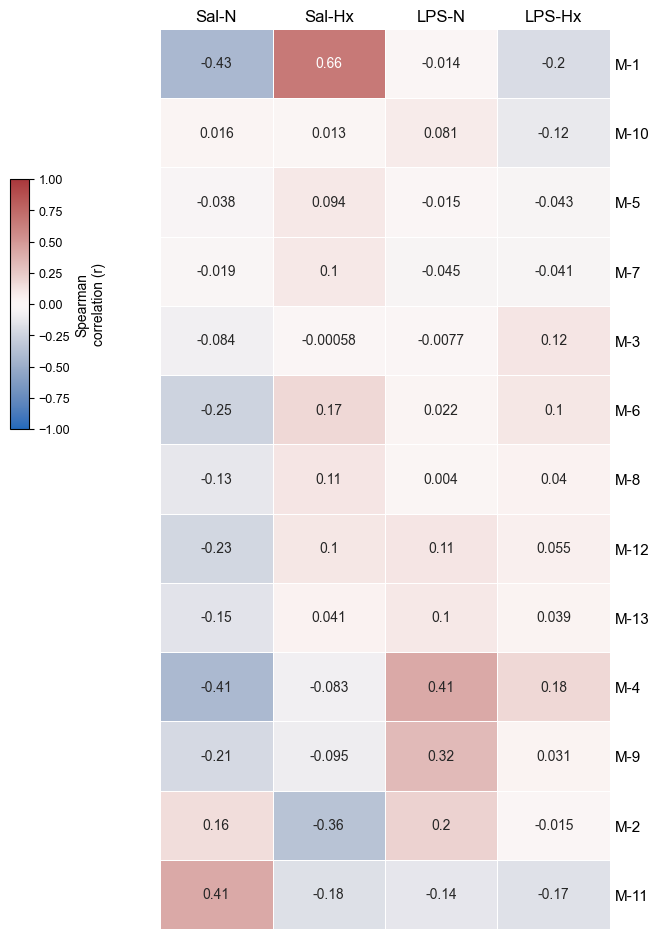

In [4]:
g = sns.clustermap(
    corr,
    annot=True,
    fmt='.2g',
    col_cluster=False,
    cmap=sns.color_palette('vlag', as_cmap=True),
    vmin=-1, vmax=1,
    figsize=(7.5, 10),
    cbar_pos=None,
    dendrogram_ratio=(0.001, 0.001),
    linewidths=0.4, linecolor='white',
)

g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

# Place the heatmap with room on the left for an external colorbar
g.ax_heatmap.set_position([0.30, 0.05, 0.60, 0.90])

g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='x', rotation=0, length=0, labelsize=12)
g.ax_heatmap.tick_params(axis='y', rotation=0, length=0, labelsize=11)

# x labels on top, y labels on the right (manuscript style)
g.ax_heatmap.xaxis.tick_top()
g.ax_heatmap.xaxis.set_label_position('top')
g.ax_heatmap.yaxis.tick_right()

# External slim vertical colorbar at upper-left
cbar_ax = g.fig.add_axes([0.10, 0.55, 0.025, 0.25])
cbar = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cbar_ax)
cbar.set_label('Spearman\ncorrelation (r)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

out_pdf = OUT_DIR / 'Fig3B.pdf'
out_png = OUT_DIR / 'Fig3B.png'
g.savefig(out_pdf)
g.savefig(out_png, dpi=300)
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')
plt.show()

## Row order after clustering — sanity check vs published Fig 3B
Published Fig 3B order (top → bottom): M-1, M-10, M-5, M-7, M-3, M-6, M-8, M-12, M-13, M-4, M-9, M-2, M-11.

In [5]:
row_order = [corr.index[i] for i in g.dendrogram_row.reordered_ind]
print('My row order (top -> bottom):')
print(row_order)
print('\nPublished Fig 3B order:')
print(['M-1','M-10','M-5','M-7','M-3','M-6','M-8','M-12','M-13','M-4','M-9','M-2','M-11'])
print('\nMatch:', row_order == ['M-1','M-10','M-5','M-7','M-3','M-6','M-8','M-12','M-13','M-4','M-9','M-2','M-11'])

My row order (top -> bottom):
['M-1', 'M-10', 'M-5', 'M-7', 'M-3', 'M-6', 'M-8', 'M-12', 'M-13', 'M-4', 'M-9', 'M-2', 'M-11']

Published Fig 3B order:
['M-1', 'M-10', 'M-5', 'M-7', 'M-3', 'M-6', 'M-8', 'M-12', 'M-13', 'M-4', 'M-9', 'M-2', 'M-11']

Match: True
